In [1]:
%env NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/
import sys

env: NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/


In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random

from alertstack.analyse import Analyse
from alertstack.fixed_catalogues.icecube_neutrino_alerts import (
    HealpixNeutrinoAlertCatalogue
)
from alertstack.scramble_catalogues.agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)

from alertstack.scramble_catalogues.flaires_catalogue import (
    FlairesCatalogue, FluencebolHypothesis
)
from scipy import interpolate
from scipy.optimize import bisect
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

/data/user/gsommani/test-venv-python3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_sens(
    catalog,
    hypos,
    nucat,
    min_E,
    cache_dir,
    old_res_path,
    fraction=0.3,
    n_steps=15,
    n_trials=50,
    progression_bar=True,
    tag="",
    max_workers=4,
    chunksize=4,
):
    additional_tag = f"{tag}_E_min_{min_E}"
    analysis = Analyse(
        catalog,
        hypos,
        nucat,
        cache_dir=cache_dir,
        min_E = min_E,
        clean_cache=False
    )
    analysis.set_injection_hypo(hypos[0], min_E)
    fs = [0. for i in range(n_trials)]
    min_frac = 0.0
    for step in np.linspace(min_frac, fraction, n_steps + 1)[1:]:
        fs += [step for _ in range(n_trials)]
    
    inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]
    
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
        )
    
    all_res = dict()
    
    # Combine results into nested dictionaries
    
    for fraction in sorted(list(set(fs))):
        mask = np.array(fs) == fraction
        cut_results = np.array(results)[mask]
        res_dict = cut_results[0]
        for entry in cut_results[1:]:
            for key, val in entry.items():
                res_dict[key] += val
    
        for key in res_dict.keys():
            res_dict[key] = np.array(res_dict[key])
        all_res[fraction] = res_dict
    
    analysis.all_res = all_res
    
    analysis.dump_results(additional_tag=additional_tag)

    results = glob.glob(analysis.cache_dir + "/" + additional_tag + "*")
    new_res = results[0]
    old_res = old_res_path
    
    with open(new_res, "rb") as f:
        new_res_dict = pickle.load(f)
    with open(old_res, "rb") as f:
        old_res_dict = pickle.load(f)
    
    sens_threshold = dict()
    for key, val in old_res_dict[0.].items():
        sens_threshold[key] = np.median(val)

    levels = [
        ("Background Median", sens_threshold),
    ]
    
    above = dict()
    
    # Calculate for each step the fraction of trials that are above a certain threshold
    # and store the information in the 'above' dictionary
    for step, res in new_res_dict.items():
    
        bkgs = dict()
        temp = []
    
        for key, val in res.items():
            val = np.array(val)
    
            for name, thresh in levels:
                temp.append(np.sum(val > thresh[key])/float(len(val)))        
        above[step] = temp
    
    fracs = list(above.keys())
    sens = [list(above.values())[i][0] for i in range(len(fracs))]
    
    # Interpolate a curve to the data points of the fraction of trials above each threshold
    f1 = interpolate.interp1d(fracs, sens, kind='cubic')
    
    frs = np.linspace(min(fracs), max(fracs), 100)
    plt.scatter(fracs, sens, marker="o")
    plt.plot(frs, f1(frs))
    plt.axhline(0.9, color="red", linestyle="dotted")
    plt.axvline(0.036, color="black", linestyle="dotted")
    plt.show()
    plt.close()
    
    # Calculate average signalness and number of neutrino alerts
    tmp = [i.weight for i in analysis.fixed_sources]
    avg_signalness = np.mean(tmp)
    n_events = len(tmp)
    
    # Calculate flux needed to achieve sensitivity and discovery potential 
    print(
        "\n------- Sensitivity and discovery potential with "
        "{0} neutrino alerts (average signalness: {1:.1f} %, min_E: {2:.0f} TeV) --------\n".format(
            n_events, 100*avg_signalness, min_E
        )
    )
    
    x1 = bisect(
        lambda x: f1(x)-0.9,
        min_frac,
        fraction,
        xtol=1e-6
    )
    
    print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
                x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
    print("\n----------------------------------------------------------------------------------------------------------\n")

    return x1

100%|██████████| 800/800 [03:20<00:00,  3.99it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_10.02026_01_15-15_14_17.pkl


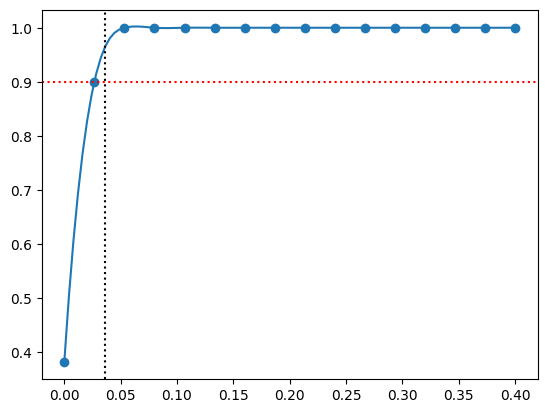


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 10 TeV) --------

Sensitivity at 0.027 of flux, expectation of 4.8/387 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [03:20<00:00,  4.00it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_31.111111111111112026_01_15-15_17_48.pkl


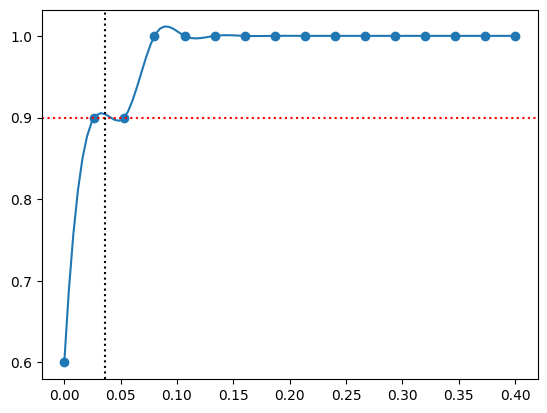


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 31 TeV) --------

Sensitivity at 0.053 of flux, expectation of 9.7/387 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [03:20<00:00,  3.99it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_52.222222222222222026_01_15-15_21_20.pkl


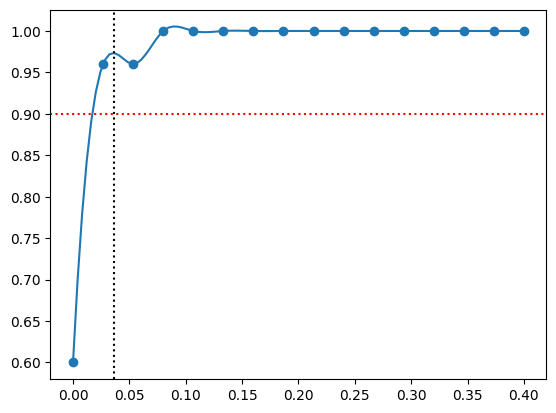


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 52 TeV) --------

Sensitivity at 0.017 of flux, expectation of 3.1/387 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [03:17<00:00,  4.05it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_73.333333333333332026_01_15-15_24_49.pkl


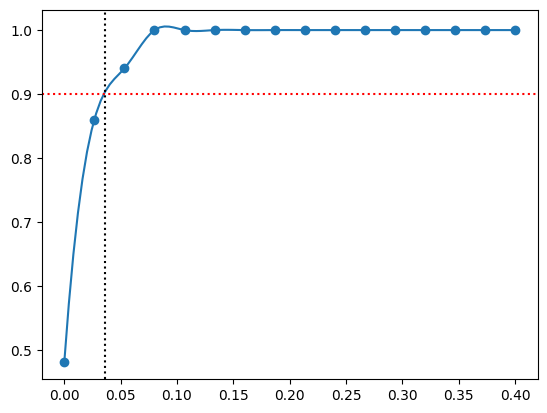


------- Sensitivity and discovery potential with 380 neutrino alerts (average signalness: 46.8 %, min_E: 73 TeV) --------

Sensitivity at 0.035 of flux, expectation of 6.2/380 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [03:16<00:00,  4.07it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_94.444444444444442026_01_15-15_28_18.pkl


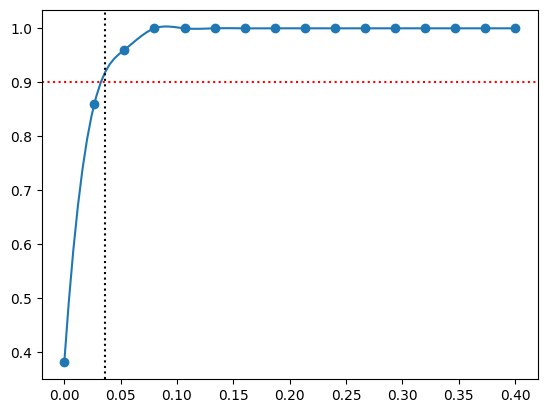


------- Sensitivity and discovery potential with 374 neutrino alerts (average signalness: 46.9 %, min_E: 94 TeV) --------

Sensitivity at 0.032 of flux, expectation of 5.7/374 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [02:33<00:00,  5.20it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_115.555555555555562026_01_15-15_31_03.pkl


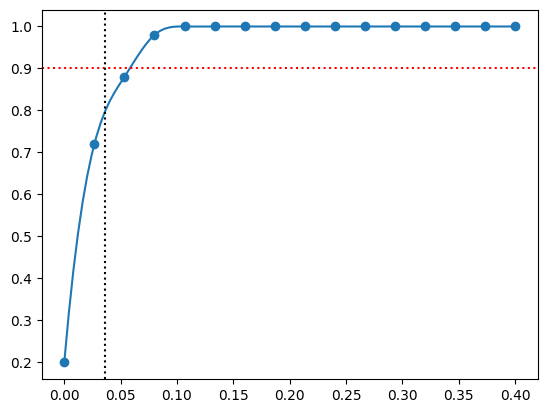


------- Sensitivity and discovery potential with 293 neutrino alerts (average signalness: 50.7 %, min_E: 116 TeV) --------

Sensitivity at 0.058 of flux, expectation of 8.6/293 = 0.03

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [02:05<00:00,  6.36it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_136.666666666666662026_01_15-15_33_20.pkl


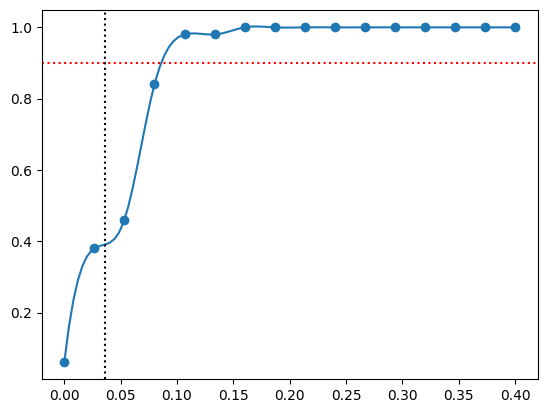


------- Sensitivity and discovery potential with 240 neutrino alerts (average signalness: 53.7 %, min_E: 137 TeV) --------

Sensitivity at 0.086 of flux, expectation of 11.1/240 = 0.05

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [01:39<00:00,  8.03it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_157.777777777777772026_01_15-15_35_11.pkl


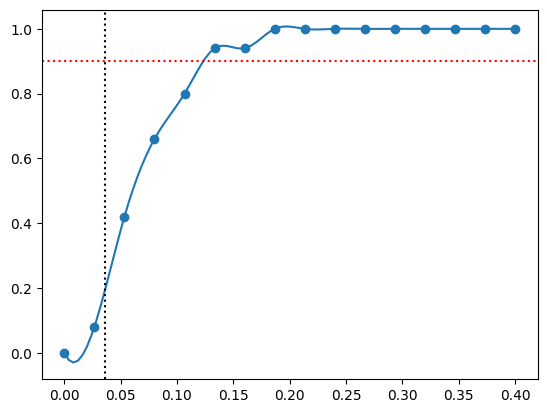


------- Sensitivity and discovery potential with 185 neutrino alerts (average signalness: 56.9 %, min_E: 158 TeV) --------

Sensitivity at 0.123 of flux, expectation of 13.0/185 = 0.07

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [01:09<00:00, 11.56it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_178.888888888888892026_01_15-15_36_31.pkl


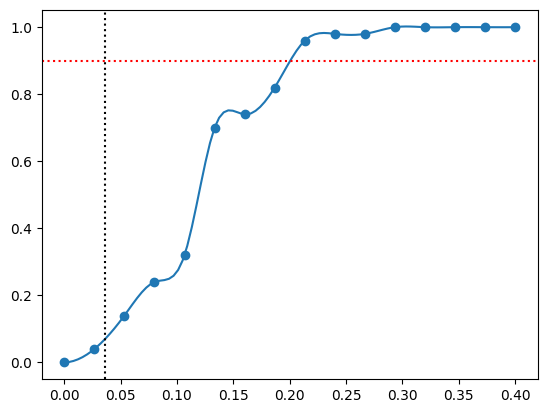


------- Sensitivity and discovery potential with 129 neutrino alerts (average signalness: 61.4 %, min_E: 179 TeV) --------

Sensitivity at 0.200 of flux, expectation of 15.9/129 = 0.12

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [00:50<00:00, 16.00it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_200.02026_01_15-15_37_32.pkl


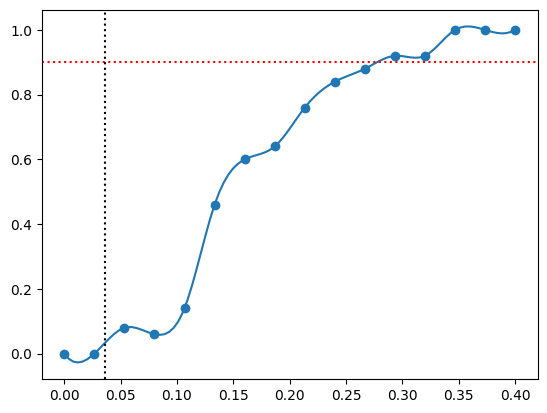


------- Sensitivity and discovery potential with 96 neutrino alerts (average signalness: 63.6 %, min_E: 200 TeV) --------

Sensitivity at 0.277 of flux, expectation of 16.9/96 = 0.18

----------------------------------------------------------------------------------------------------------



In [7]:
es = np.linspace(10,200,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        AstrogeoAGNCatalogue(),
        [AverageFluxWeightHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.4,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/New_Updated_Alerts_Stacking/examples/"
            "radio_agn_neutrino_alert/cache/2026_01_09-16_27_14.pkl"
        ),
        tag="radio_agn"
    ))

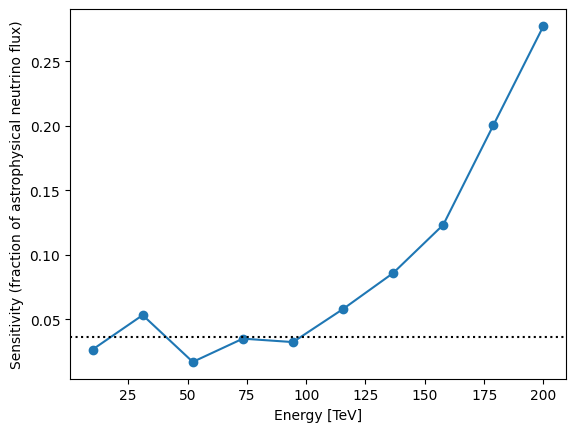

In [8]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.036, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.savefig("e_min_radio_agn", dpi=150)

Found 524 sources in total


100%|██████████| 1600/1600 [04:53<00:00,  5.46it/s]


/data/user/gsommani/alertstack-icecube/flaires_zoom_E_min_50.02026_01_15-16_36_16.pkl


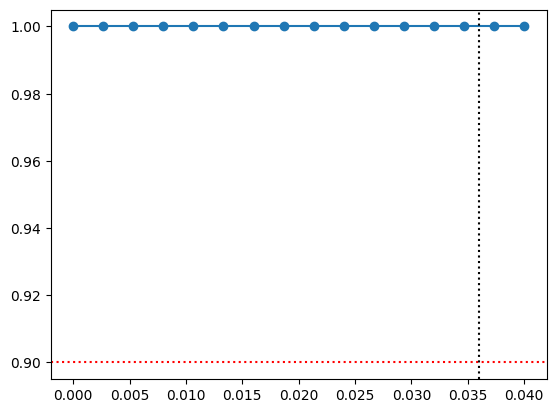


------- Sensitivity and discovery potential with 304 neutrino alerts (average signalness: 47.2 %, min_E: 50 TeV) --------



ValueError: f(a) and f(b) must have different signs

In [4]:
es = np.logspace(np.log10(40),np.log10(500),10)
es = np.linspace(50,150,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        FlairesCatalogue(),
        [FluencebolHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.04,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/alertstack_results/flaires_n2000000_f0.07_s10.pkl"  
        ),
        tag="flaires_zoom",
        max_workers=4,
        chunksize=4,
        n_trials=100
    ))

In [11]:
obj = FlairesCatalogue()

Found 524 sources in total


In [13]:
obj.

TypeError: Catalogue.bkg_spatial_pdf() missing 2 required positional arguments: 'ra' and 'dec'

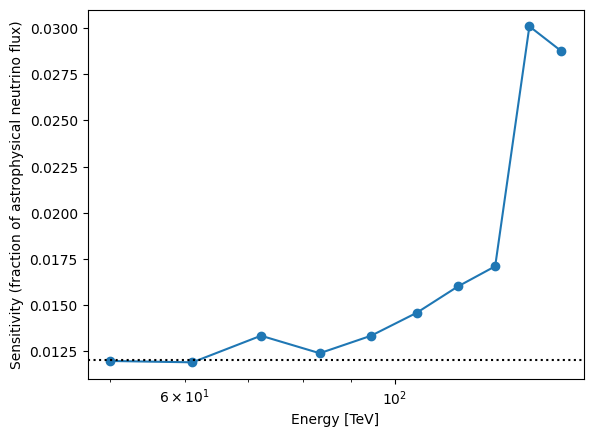

In [22]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires_zoom", dpi=150)

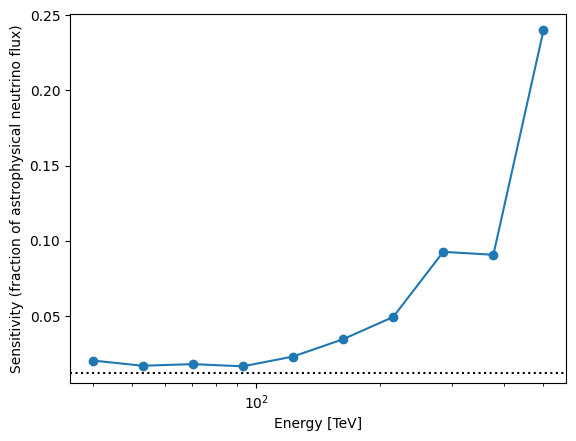

In [16]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires", dpi=150)

In [37]:
agn_analysis = Analyse(
    AstrogeoAGNCatalogue(),
    [AverageFluxWeightHypothesis],
    HealpixNeutrinoAlertCatalogue(),
    cache_dir=os.getcwd(),
    min_E = 0,
    clean_cache=False
)

In [11]:
es = np.array([nu.energy for nu in agn_analysis.fixed_sources])
len(es), es

(365,
 array([ 161.  ,  134.  ,  139.  ,  154.  ,   85.  ,  237.  ,  109.  ,
         151.  ,  126.77,  105.  ,  126.  ,  126.  ,  109.  ,  161.47,
         416.  ,  116.  ,  115.  ,  122.  ,  122.  ,  106.  ,  123.  ,
         231.  ,  140.  ,   62.  ,  113.  ,  214.  ,  109.5 ,  163.  ,
         186.  ,  107.  ,   56.  ,  106.  ,  160.  ,  107.  ,  135.  ,
         107.  ,  208.  ,  184.  ,  439.  ,  144.  ,  110.  ,  110.  ,
         111.  ,  116.  ,  121.26,  208.  ,  168.  ,  193.  ,  202.  ,
         263.  ,  153.  ,  212.  ,  191.  ,  121.  ,  124.  , 3114.  ,
         143.  ,  133.  ,  267.79,   55.  ,  108.  ,  195.  ,  321.  ,
         114.  ,  133.  ,  108.  ,  109.  ,  961.  ,  216.  ,  217.  ,
         118.  ,  105.44,  155.  ,  155.  ,  228.  ,  218.  ,  188.  ,
         115.  ,  374.  ,  152.  ,  188.  ,  168.  ,  140.  ,  110.  ,
         139.  ,  198.  ,  161.  ,   55.  ,  128.  ,  113.  ,  373.  ,
         216.  ,  110.  ,  200.  ,  109.  ,  117.  ,  160.  ,  106.  ,


In [4]:
agn_analysis.set_injection_hypo(AverageFluxWeightHypothesis)

In [31]:
fraction = 0.06
n_steps = 10
n_trials = 100
progression_bar = True
additional_tag = "E_min_100"

fs = []
for step in np.linspace(0.0, fraction, n_steps + 1)[1:]:
    fs += [step for _ in range(n_trials)]

inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]

if 'Healpix' not in type(agn_analysis.fixed_sources).__name__:
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        agn_analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
    )
    
else:
    results = []
    if progression_bar:
        for i in tqdm(range(len(inputs))):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
    else:
        t0 = time.time()
        for i in range(len(inputs)):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
if not progression_bar:
    sys.stderr = sys.__stderr__
    t1 = time.time()
    print(f"Job completed. Time taken:{(t1-t0)/3600} hours")

all_res = dict()

# Combine results into nested dictionaries

for fraction in sorted(list(set(fs))):
    mask = np.array(fs) == fraction
    cut_results = np.array(results)[mask]
    res_dict = cut_results[0]
    for entry in cut_results[1:]:
        for key, val in entry.items():
            res_dict[key] += val

    for key in res_dict.keys():
        res_dict[key] = np.array(res_dict[key])
    all_res[fraction] = res_dict

agn_analysis.all_res = all_res

agn_analysis.dump_results(additional_tag=additional_tag)

100%|██████████| 1000/1000 [08:48<00:00,  1.89it/s]


In [39]:
additional_tag = "E_min_0"
results = glob.glob(agn_analysis.cache_dir + "/" + additional_tag + "*")
new_res = results[0]
old_res = (
    "/data/user/gsommani/New_Updated_Alerts_Stacking/"
    "examples/radio_agn_neutrino_alert/cache/2025_10_27-10_16_09.pkl"
)
with open(new_res, "rb") as f:
    new_res_dict = pickle.load(f)
with open(old_res, "rb") as f:
    old_res_dict = pickle.load(f)

sens_threshold = dict()
for key, val in old_res_dict[0.].items():
    sens_threshold[key] = np.median(val)

In [43]:
levels = [
    ("Background Median", sens_threshold),
]

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in new_res_dict.items():

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in agn_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0.006, 0.06, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")


------- Sensitivity and discovery potential with 365 neutrino alerts (average signalness: 45.1 %) --------

Sensitivity at 0.033 of flux, expectation of 5.4/365 = 0.01

----------------------------------------------------------------------------------------------------------



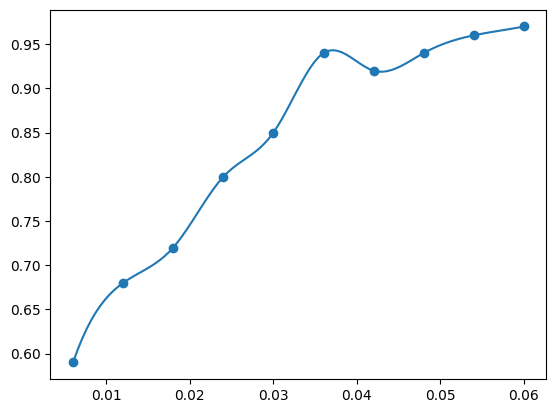

In [41]:
frs = np.linspace(min(fracs), max(fracs), 100)
plt.scatter(fracs, sens, marker="o")
plt.plot(frs, f1(frs))